In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

import utilities as utils
import care

# Training a global operator on synthetic data

### Stationary synthetic dataset

In the synthetic case, the stationary time series include pure 10Hz signals, 24Hz signals, as well as their sum. This is displayed below.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



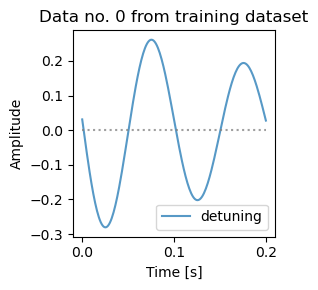

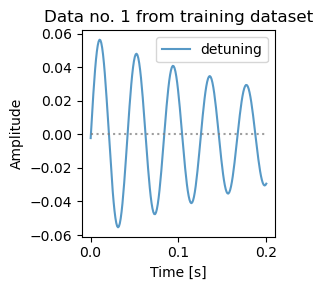

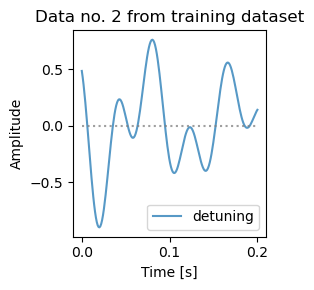

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

datadir               = 'data/train_sim_g'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.001

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils.disp_dataset(datadir, timeseries_nsample, timestep)


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



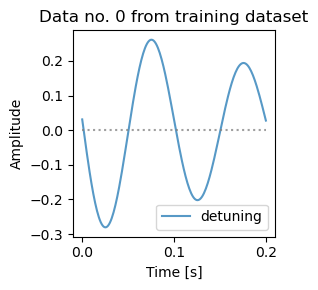

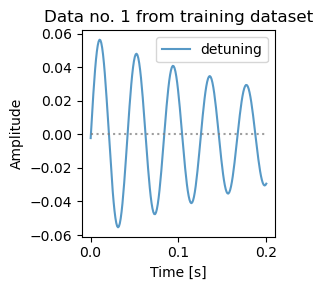

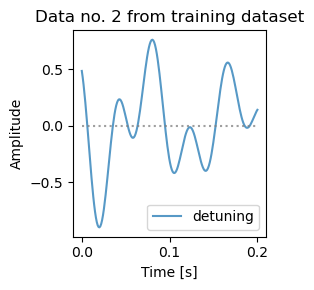

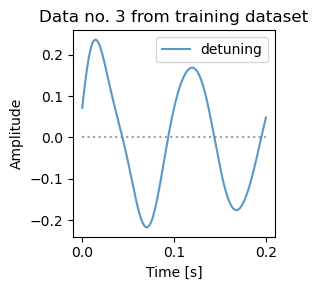

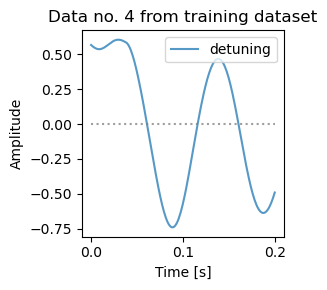

In [3]:
# --!------------------------------------------------------!
# --! display dataset metrics

datadir               = 'data/train_sim_mix'
timeseries_ndim       = 1
timeseries_nsample    = 200
timestep              = 0.001

# --! subtimeseries give us additional flexibility by allowing to work with subportions
# --! of original sampled timeseries
subtimeseries_nsample = timeseries_nsample

utils.disp_dataset(datadir, timeseries_nsample, timestep, ndata=5)

### Model instantiation

The model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We set parameter $\tau=40$, as this value allows the DMD-like global operator to consistently identify two distinct complex eigenvalue pairs corresponding to the fast and slow oscillatory modes.

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model_cfg = care.detuning_config(

    timeseries_ndim    = timeseries_ndim,
    timeseries_nsample = subtimeseries_nsample, # by using subtimeseries we may work with fewer samples than originally sampled
    timestep           = timestep,

    fun = {
        'poly_1' : 1,
        'poly_2' : 1,
        'poly_3' : 1,
        'poly_4' : 1,
    },

    param_kernsize     = 40
)

model = care.detuning(model_cfg)

### Model training

In [5]:
# --!--------------------------------------------------------------------------
# --! train the stationary DMD-like operator

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : 'data/train_sim_g',
    'transdatadir'          : 'data/train_sim_l',
    'mixdatadir'            : 'data/train_sim_mix',
    'timeseries_nsample'    : timeseries_nsample,
    'subtimeseries_nsample' : subtimeseries_nsample,
    'alphafun'              : None,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'isstaonly'             : True,
    'ismeanonly'            : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-8,
}

loss = []

while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> fit: entering dynamic phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4

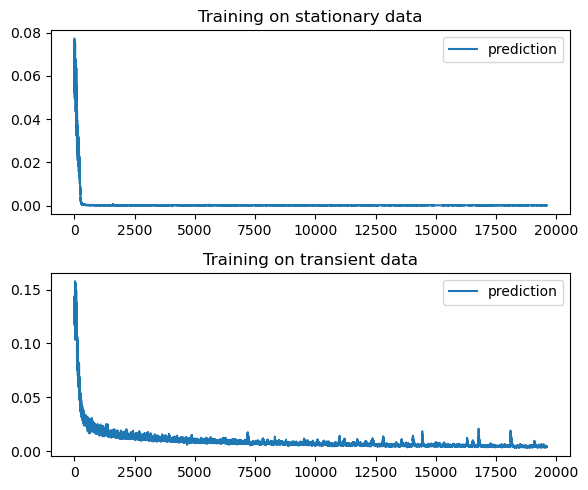

In [6]:
# --!--------------------------------------------------------------------------
# --! plot training statistics

with torch.no_grad():
    sta_stats = loss[0]
    dyn_stats = loss[2]

    plt.figure(figsize=(6, 5))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(sta_stats[0], label='prediction')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(dyn_stats[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.operator_sta.model.weight)

if savemod_on:
    torch.save(model, 'models/kind_sim.pt')

Parameter containing:
tensor([[ 0.2284, -0.5099, -0.7933, -0.2741],
        [-0.2635, -0.0113, -0.2229,  0.5139],
        [-0.5481,  0.7068, -0.2868, -0.7256],
        [ 0.2924,  0.8235, -0.0758,  0.2988]])


In [8]:
model.eval()

with torch.no_grad():
    fun_bank = []
    fun_predict_bank = []

    for ifile in range(trainparam['train_nfile']):
        traindata     = utils.read_datafile(f'{trainparam['transdatadir']}/train{ifile + 1}', trainparam['timeseries_nsample'])
        traindataset  = torch.utils.data.TensorDataset(traindata)
        traindatafun  = torch.utils.data.DataLoader(traindataset, batch_size=trainparam['batsize'], shuffle=False)

        for data in traindatafun:
            timeseries = data[0][:, :trainparam['subtimeseries_nsample'], :1]
            timeseries_predict, fun, fun_predict = model.operator_dyn(timeseries)

            fun_bank.append(fun)
            fun_predict_bank.append(fun_predict)

    trainfun = torch.cat(fun_bank, dim=0)
    trainfun_predict = torch.cat(fun_predict_bank, dim=0)
    trainfun = torch.cat([trainfun, trainfun_predict], dim=-1)
    trainfun = trainfun.reshape(-1, trainfun.shape[-1])
    print(trainfun.shape)


torch.Size([122500, 8])


In [9]:
with torch.no_grad():
    fun_bank = []
    fun_predict_bank = []

    validdata     = utils.read_datafile(f'{trainparam['transdatadir']}/valid', trainparam['timeseries_nsample'])
    validdataset  = torch.utils.data.TensorDataset(validdata)
    validdatafun  = torch.utils.data.DataLoader(validdataset, batch_size=trainparam['batsize'], shuffle=False)

    for data in validdatafun:
        timeseries = data[0][:, :trainparam['subtimeseries_nsample'], :1]
        timeseries_predict, fun, fun_predict = model.operator_dyn(timeseries)

        fun_bank.append(fun)
        fun_predict_bank.append(fun_predict)

    validfun = torch.cat(fun_bank, dim=0)
    validfun_predict = torch.cat(fun_predict_bank, dim=0)
    validfun = torch.cat([validfun, validfun_predict], dim=-1)
    validfun = validfun.reshape(-1, validfun.shape[-1])
    print(validfun.shape)


torch.Size([5000, 8])


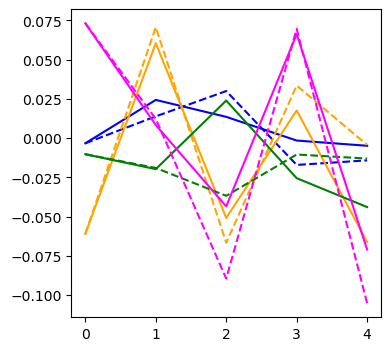

In [21]:
with torch.no_grad():
    fun_bank = []
    fun_predict_bank = []

    testdata = utils.read_datafile('data/eval_sim/eval', trainparam['timeseries_nsample'])

    timeseries = torch.unsqueeze(testdata[0][:trainparam['subtimeseries_nsample'], :1], 0)
    timeseries_predict, fun, fun_predict = model.operator_dyn(timeseries)

    fun_bank.append(fun)
    fun_predict_bank.append(fun_predict)

    testfun = torch.cat(fun_bank, dim=0)
    testfun_predict = torch.cat(fun_predict_bank, dim=0)
    testfun = torch.cat([testfun, testfun_predict], dim=-1)
    testfun = testfun.reshape(-1, testfun.shape[-1])

    plt.figure(figsize=(4,4))
    plt.plot(fun[0, :, 0], color='blue', linestyle='solid')
    plt.plot(fun_predict[0, :, 0], color='blue', linestyle='dashed')
    plt.plot(fun[0, :, 1], color='orange', linestyle='solid')
    plt.plot(fun_predict[0, :, 1], color='orange', linestyle='dashed')
    plt.plot(fun[0, :, 2], color='green', linestyle='solid')
    plt.plot(fun_predict[0, :, 2], color='green', linestyle='dashed')
    plt.plot(fun[0, :, 3], color='magenta', linestyle='solid')
    plt.plot(fun_predict[0, :, 3], color='magenta', linestyle='dashed')
    plt.show()


torch.Size([2, 8])
torch.Size([2, 8])


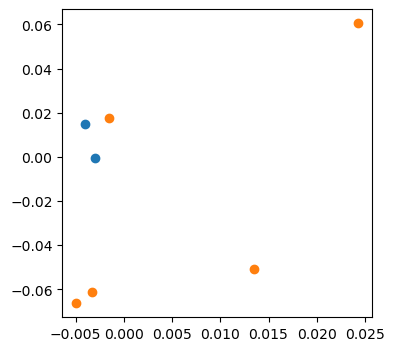

tensor([0.1243, 0.1004, 0.1526, 0.0932, 0.1343], dtype=torch.float64)


In [22]:
def compute_embedding_uncertainty(z_test, centroids):
    dist = z_test.unsqueeze(1) - centroids
    norm = torch.linalg.vector_norm(dist, dim=-1)
    return torch.min(norm, -1)[0]

with torch.no_grad():

    trainkmeans = KMeans(n_clusters=2).fit(trainfun)
    traincentroids = torch.tensor(trainkmeans.cluster_centers_)
    print(traincentroids.shape)

    validkmeans = KMeans(n_clusters=2).fit(validfun)
    validcentroids = torch.tensor(validkmeans.cluster_centers_)
    print(validcentroids.shape)

    plt.figure(figsize=(4,4))
    plt.scatter(traincentroids[:, 0], traincentroids[:, 1])
    plt.scatter(testfun[:, 0], testfun[:, 1])
    plt.show()

    unc = compute_embedding_uncertainty(testfun, traincentroids)
    print(unc)

# Training $\alpha$ function that depends on input timeseries

The $\alpha$ function is supposed to differentiate between stationary and transient data. The function is implemented in terms of a classifier neural network that is trained in a supervised manner on timeseries data. Of course, for supervised learning we need labels.

### Dataset with labels

To create labels for our data, we take advantage of our trained DMD-like global operator. Specifically, we leverage the residual of the DMD operator as a threshold---if the operator is able to successfully approximate given data, then these are stationary data; otherwise the data are non-stationary.

So first find the maximum DMD residual, such that all global synthetic data are labeled as stationary.

In [12]:
# --!--------------------------------------------------------------------------
# --! determine a maximum DMD residual for a stationary dataset

dmd_residual_max  = 1.2e-3
labels_stationary = utils.label_stationarity(model, dmd_residual_max, 'data/train_sim_g', timeseries_nsample)

# --! print the number of timeseries still identified as non-stationary
nonstationary_n = len(torch.nonzero(~labels_stationary))
print(' ')
if nonstationary_n == 0:
    print(f'inf >> all data are labeled as stationary when maximum residual is {dmd_residual_max:.1e}')
else:
    print(f'wrn >> there are still {nonstationary_n} data labeled as non-stationary')
print(' ')


 
wrn >> there are still 3 data labeled as non-stationary
 


Then use the maximum residual to create a labeled dataset.

In [13]:
# --!--------------------------------------------------------------------------
# --! create a stationarity dataset from stationary and transient data

stationarity_dataset = utils.create_stationarity_dataset(
    model,
    dmd_residual_max,
    [
        'data/train_sim_g',
        'data/train_sim_l'
    ],
    timeseries_nsample)

### Neural network as $\alpha$ function

In [14]:
# --!--------------------------------------------------------------------------
# --! load or train a classifier network

alpha_fun_loaded = True

if alpha_fun_loaded:
    alpha_fun = torch.load('models/alpha_fun.pt', weights_only=False)
else:
    alpha_fun_cfg = care.alpha_fun_config(
        kern_sz = 43
    )

    alpha_fun = care.alpha_fun(alpha_fun_cfg)

    alpha_fun_train_params = {
        'epochs_n'      : 16,
        'learning_rate' : 8e-3,
        'batsize'       : 16,
        'weight_decay'  : 1e-8
    }

    utils.train_alpha_fun(alpha_fun, stationarity_dataset, alpha_fun_train_params)

In [15]:
# --!--------------------------------------------------------------------------
# --! save a trained classifier model

savemod_on = False

if savemod_on:
    torch.save(alpha_fun, 'models/alpha_fun.pt')

# Gathering training statistics

In [16]:
# --!---------------------------------------------!
# --! helping routines

def gather_train_stats(train_params, trains_n):

    # --! placeholders for losses
    losses_train_pred = []
    losses_valid_pred = []
    losses_test_pred  = []

    for i in range(trains_n):
        this = i + 1
        print(f'inf >> iteration number {this}')

        # --! preset the random seed
        torch.manual_seed(this)

        # --! recreate a model
        model = care.detuning(model_cfg)

        # --! train the model
        outs = utils.train(model, train_params)
        loss_train_pred  = outs[0]
        loss_valid_pred  = outs[3]
        with torch.no_grad():
            losses_train_pred.append(loss_train_pred[-1])
            losses_valid_pred.append(loss_valid_pred[-1])

        # --! test the model
        with torch.no_grad():
            loss_test_pred = utils.test(model, train_params)
            losses_test_pred.append(np.mean(loss_test_pred))

    return losses_train_pred, losses_valid_pred, losses_test_pred

def disp_train_stats(stats, iters_n, operator: str='Global'):
    """Prints training statistics."""
    losses_train_pred = stats[0]
    losses_valid_pred = stats[1]
    losses_test_pred  = stats[2]

    train_mean = np.mean(losses_train_pred)
    valid_mean = np.mean(losses_valid_pred)
    test_mean  = np.mean(losses_test_pred)

    train_std  = np.std(losses_train_pred)
    valid_std  = np.std(losses_valid_pred)
    test_std   = np.std(losses_test_pred)

    # --! compile statistics
    stats_table = [
        (            '',          'Training',        'Validation',                               'Test'),
        ('------------',      '------------',      '------------',                 '------------------'),
        (      operator, f'{train_mean:.1e}', f'{valid_mean:.1e}',  f'{test_mean:.1e} +- {test_std:.1e}') ]

    # --! print dataset parameters
    print('')
    print(f'inf >> training statistics for {iters_n} iteration(s):')
    print('')
    for row in stats_table:
        print(f'{row[0]:>14} {row[1]:>14} {row[2]:>14} {row[3]:>20}')
    print('')

### Global operator

In [17]:
# --!------------------------------------------------------!
# --! gather statistics

stats_on = False

if stats_on:

    # --! restore parameters to the 'global' state
    train_params['dataset_dir'] = 'data/train_sim_g'
    train_params['isdmdonly']   = True
    train_params['isverbose']   = False
    train_params['alpha_fun']   = None

    trains_n = 30

    outs = gather_train_stats(train_params, trains_n)
    losses_train_pred = outs[0]
    losses_valid_pred = outs[1]
    losses_test_pred  = outs[2]

In [18]:
# --!------------------------------------------------------!
# --! display gathered statistics

if stats_on:
    with torch.no_grad():
        disp_train_stats(outs, trains_n, 'Global')

### Local operator

In [19]:
# --!------------------------------------------------------!
# --! gather statistics

stats_on = False

if stats_on:

    # --! advance parameters to the 'local' state
    train_params['dataset_dir'] = 'data/train_sim_l'
    train_params['is_global']   = False
    train_params['is_verbose']  = False
    train_params['alpha']       = 0.5

    trains_n = 30

    outs = gather_train_stats(train_params, trains_n)

In [20]:
# --!------------------------------------------------------!
# --! display gathered statistics

if stats_on:
    with torch.no_grad():
        disp_train_stats(outs, trains_n, 'Local')